In [2]:
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
bureau = pd.read_csv("bureau.csv")
prev_loans = pd.read_csv("previous_loans.csv")

In [3]:
print(train.shape)
print(' ')
train.info()
print(' ')
train.describe()

(6488, 25)
 
<class 'pandas.DataFrame'>
RangeIndex: 6488 entries, 0 to 6487
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   application_id               6488 non-null   int64  
 1   client_id                    6488 non-null   int64  
 2   employment_type              6023 non-null   str    
 3   hash_id                      6071 non-null   float64
 4   region_coefficient_extended  6027 non-null   float64
 5   age                          6039 non-null   float64
 6   incoming_amount              6055 non-null   float64
 7   internal_decision_code       5114 non-null   str    
 8   monthly_income               6047 non-null   float64
 9   application_date             6020 non-null   str    
 10  education                    6040 non-null   str    
 11  requested_product            6106 non-null   str    
 12  channel                      5911 non-null   str    
 13  loan_amount     

,application_id,client_id,hash_id,region_coefficient_extended,age,incoming_amount,monthly_income,loan_amount,post_loan_collection_score,region_coefficient,interest_rate,months_at_job,dependents,days_until_first_overdue,loan_term_months,siberia_northern_score,target
count,6488.000000,6488.000000,6.071000e+03,6027.000000,6039.000000,6055.000000,6047.000000,5932.000000,4950.000000,6132.0,6113.000000,6102.000000,6018.000000,4632.000000,5961.000000,6056.000000,6488.000000
mean,104496.386868,4496.386868,5.503946e+07,0.005973,43.636529,42386.646533,42300.330501,77673.946999,490.591644,1.0,0.270003,102.636676,0.805085,580.034111,20.849019,0.505414,0.342170
std,2592.661534,2592.661534,2.594531e+07,0.077061,13.600516,21867.000385,21759.337138,45118.826338,225.343839,0.0,0.096328,86.869559,0.900978,436.833759,11.907587,0.288577,0.474473
min,100001.000000,1.000000,1.000185e+07,0.000000,21.000000,18000.000000,18000.000000,20000.000000,0.000000,1.0,0.080000,0.000000,0.000000,1.000000,6.000000,0.000109,0.000000
25%,102256.500000,2256.500000,3.237164e+07,0.000000,32.000000,26815.515000,26777.040000,47056.442500,320.677500,1.0,0.193000,36.000000,0.000000,97.000000,12.000000,0.257933,0.000000
50%,104518.500000,4518.500000,5.501823e+07,0.000000,44.000000,37773.110000,37717.510000,67344.210000,472.205000,1.0,0.250800,80.000000,1.000000,730.000000,18.000000,0.509269,0.000000
75%,106714.500000,6714.500000,7.818919e+07,0.000000,55.000000,52218.765000,52181.895000,96352.650000,659.425000,1.0,0.332300,149.000000,1.000000,1000.000000,24.000000,0.754349,1.000000
max,109000.000000,9000.000000,9.999550e+07,1.000000,67.000000,282686.980000,282686.980000,496150.840000,1000.000000,1.0,0.480000,506.000000,5.000000,1002.000000,48.000000,0.999899,1.000000


In [4]:
print(train.shape)
print(' ')
train.info()

(6488, 25)
 
<class 'pandas.DataFrame'>
RangeIndex: 6488 entries, 0 to 6487
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   application_id               6488 non-null   int64  
 1   client_id                    6488 non-null   int64  
 2   employment_type              6023 non-null   str    
 3   hash_id                      6071 non-null   float64
 4   region_coefficient_extended  6027 non-null   float64
 5   age                          6039 non-null   float64
 6   incoming_amount              6055 non-null   float64
 7   internal_decision_code       5114 non-null   str    
 8   monthly_income               6047 non-null   float64
 9   application_date             6020 non-null   str    
 10  education                    6040 non-null   str    
 11  requested_product            6106 non-null   str    
 12  channel                      5911 non-null   str    
 13  loan_amount     

In [ ]:
print(bureau.shape)
print(' ')
bureau.info()
print(' ')
bureau.describe()

In [ ]:
print(prev_loans.shape)
print(' ')
prev_loans.info()
print(' ')
prev_loans.describe()

In [ ]:
train['target'].value_counts(normalize=True) 
#здесь я считаю долю нулей и единиц в целевой переменной (таргете), 
# чтобы иметь это вв виду при обучении (вдруг там дисбаланс классов)

target
0    0.65783
1    0.34217
Name: proportion, dtype: float64

0 - 65.8% - доля тех, кто вернул займ
1 - 34.2% - доля тех, кто просрочил

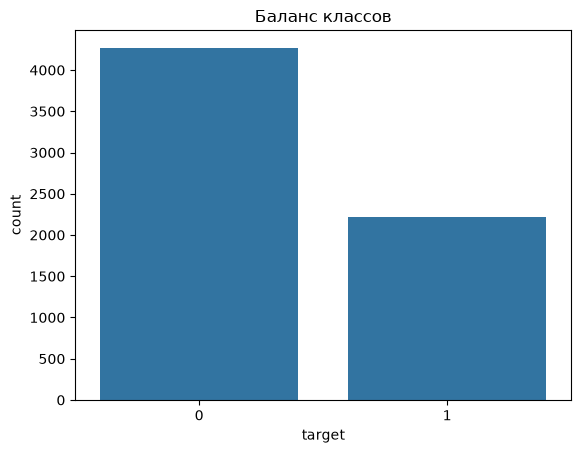

In [ ]:
sb.countplot(data=train, x='target')
plt.title('Баланс классов')
plt.show()
#ну и собственно визуализация баланса классов для таргета

По графику можно увидеть, что дисбаланс небольшой, около 2 к 1.
Это хорошо, потому что делать ничего не нужно, модель сама справится и хорошо обучится. Тем более у нас метрика Roc-AUC нечувствительна к дисюалансу.

In [7]:
train.isnull().mean().sort_values(ascending=False).head(10) 
#здесь ищем пропуски (долю пропусков) в трейн и сортируем по убыванию
#это важно, тк если окажется что в колонке слишком много пропусков,
#(более половины строк), то колонка может быть бесполечзна для обучения,
#а если пропусков совсем неного, то их можно искуственно заполнить

days_until_first_overdue      0.286067
post_loan_collection_score    0.237053
internal_decision_code        0.211776
channel                       0.088933
loan_amount                   0.085697
region                        0.084155
loan_term_months              0.081227
marketing_segment             0.078607
dependents                    0.072441
application_date              0.072133
dtype: float64

In [11]:
#то же самое для bureau
bureau.isnull().mean().sort_values(ascending=False).head(10)

bureau_status        0.051642
max_dpd_last_12m     0.034712
account_type         0.033902
credit_limit         0.033497
opened_days_ago      0.026409
current_balance      0.019442
client_id            0.000000
bureau_account_id    0.000000
dtype: float64

In [12]:
#и то же самое для previous_loans
prev_loans.isnull().mean().sort_values(ascending=False).head(10)

previous_term_months    0.050541
closed_days_ago         0.040433
max_overdue_days        0.034791
previous_amount         0.024839
was_overdue             0.020843
previous_loan_id        0.000000
client_id               0.000000
dtype: float64

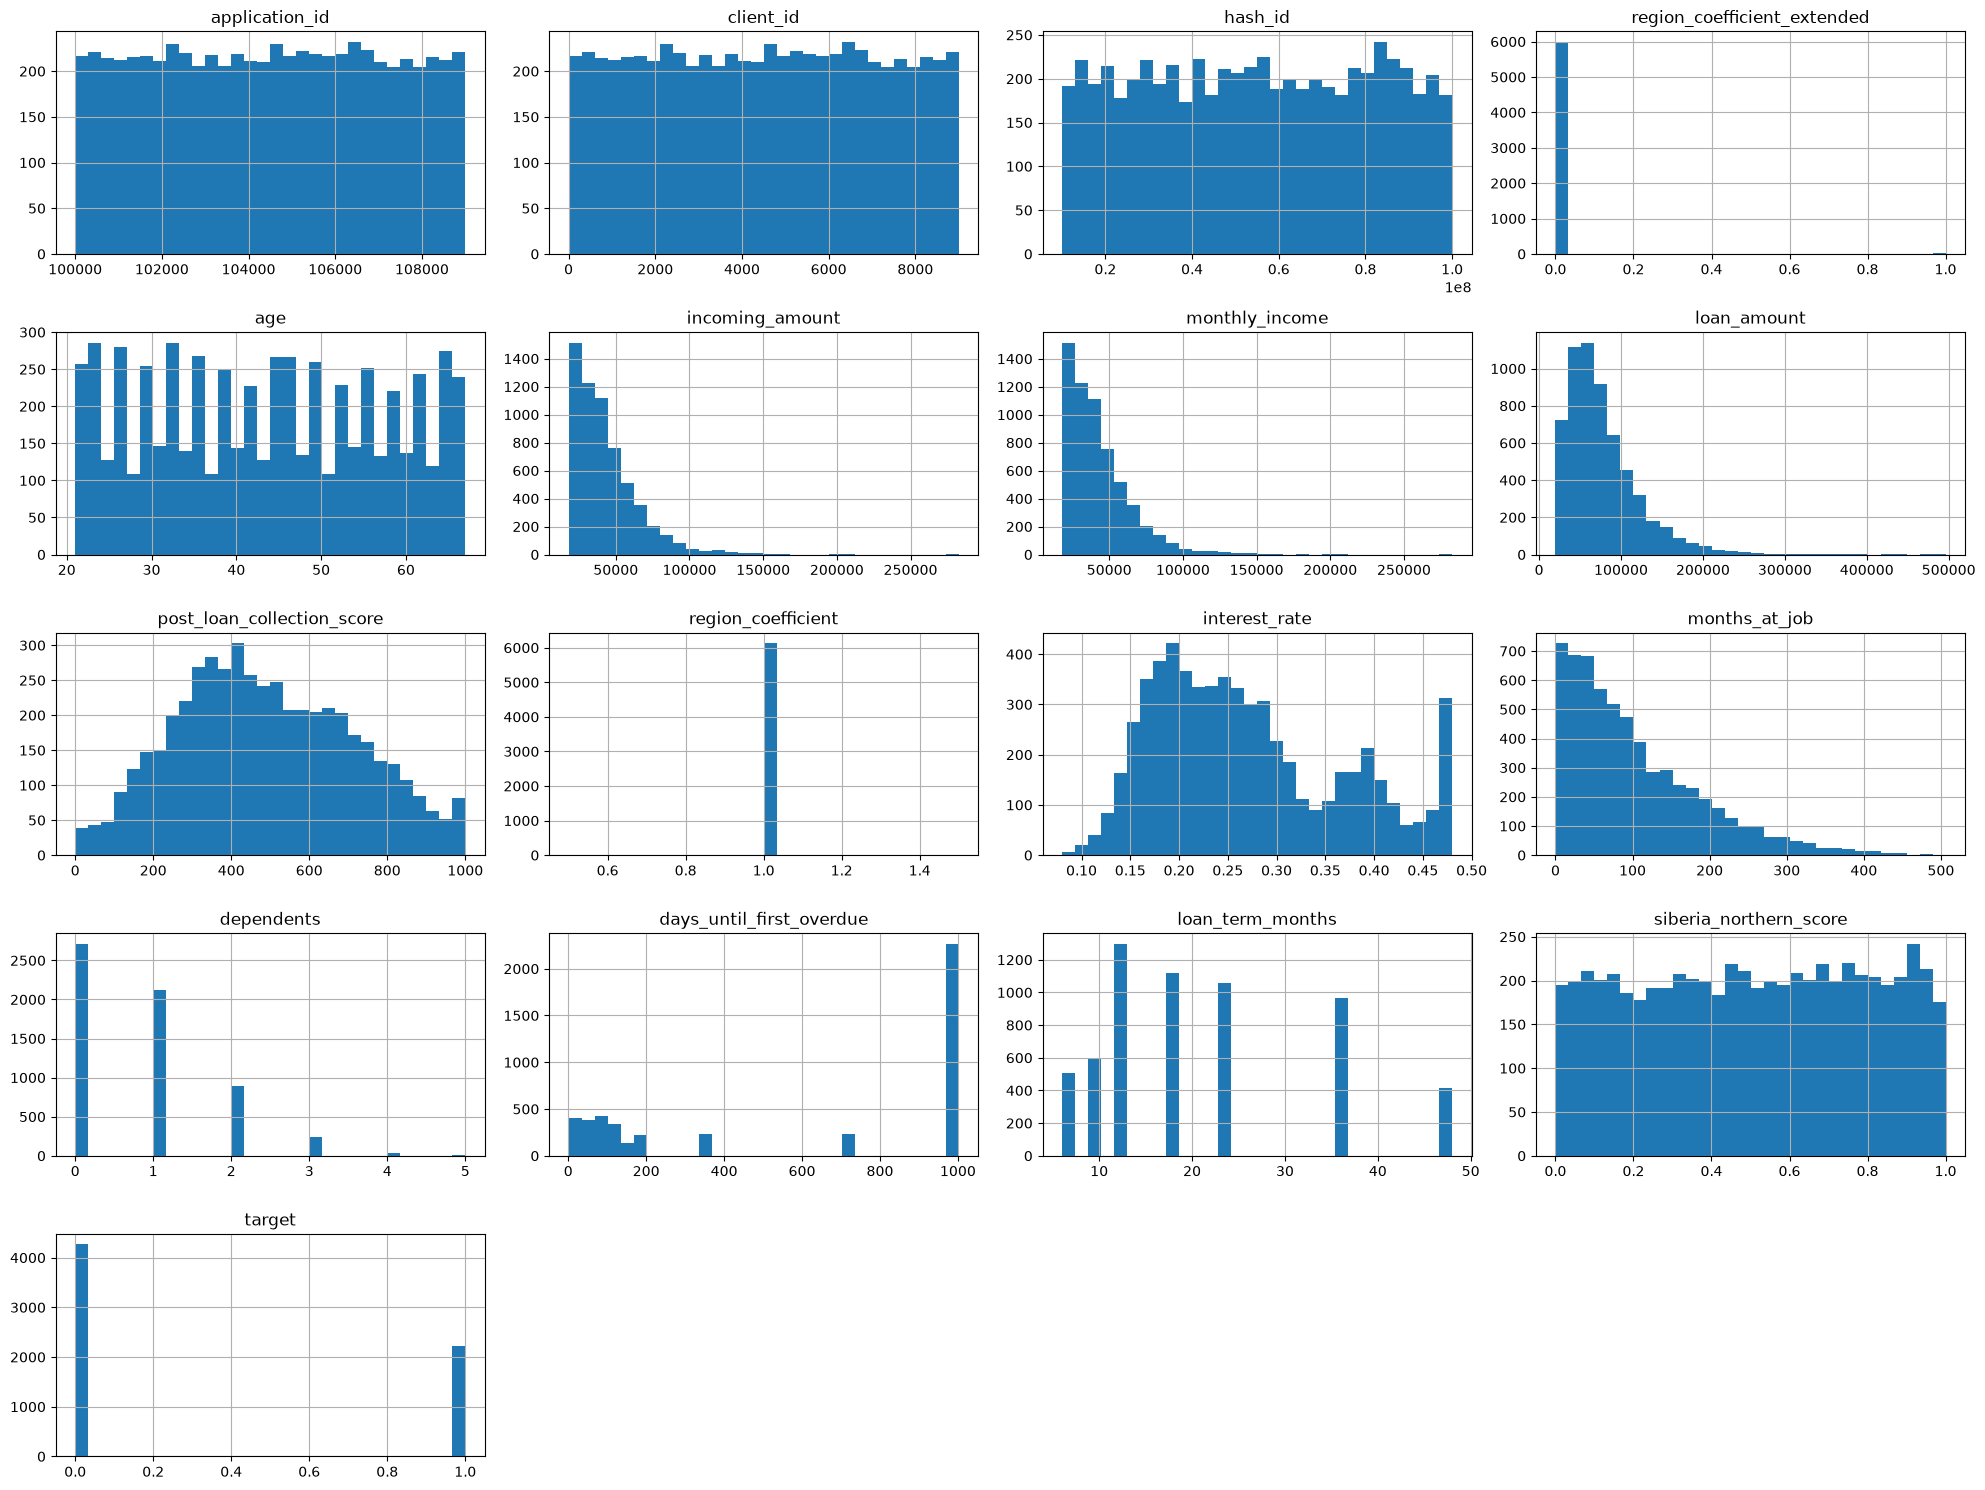

In [ ]:
train.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()
#а здесь будут гистограммы распределений по всем колонкам, 
# чтобы если что, сделать правильный feature engineering

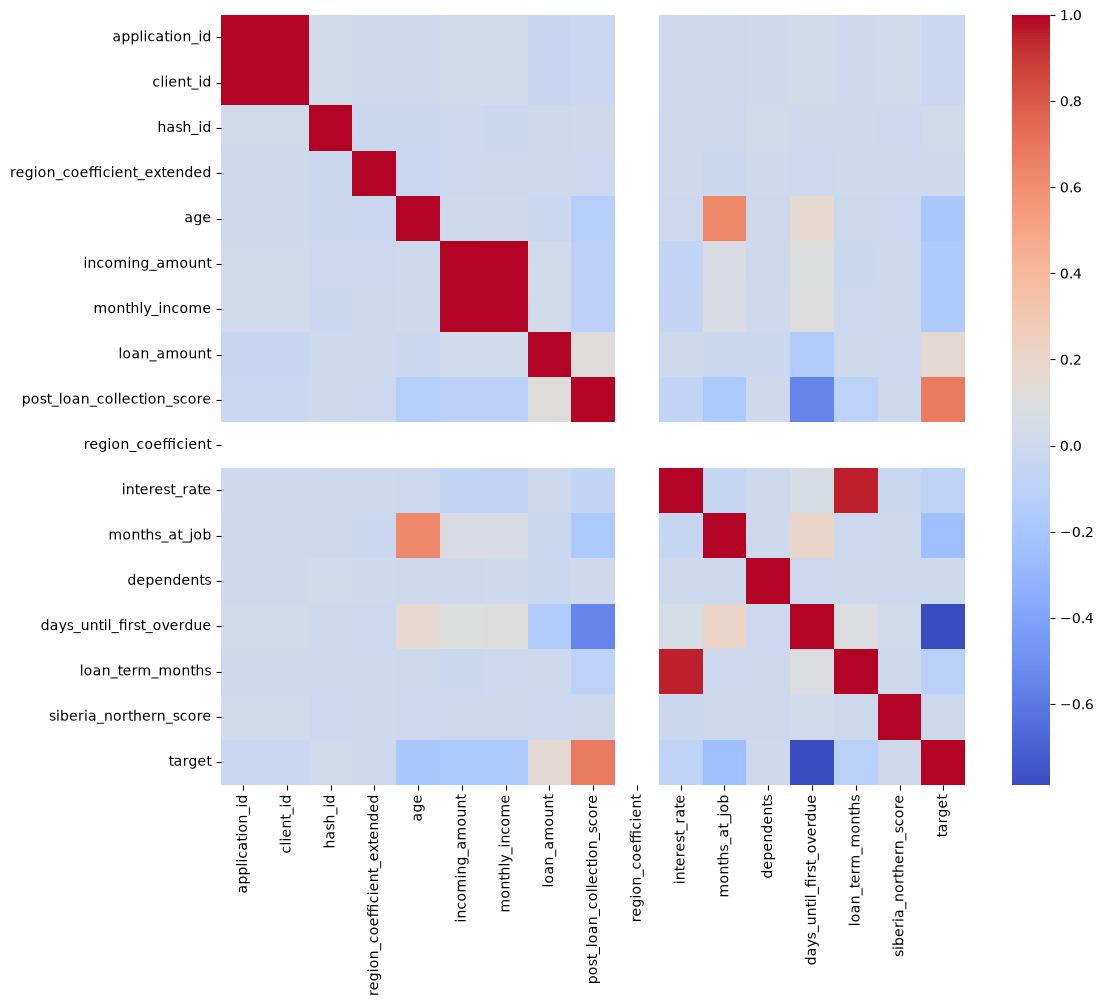

In [9]:
plt.figure(figsize=(12, 10))
sb.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.show()
#матрица корреляции, чтобы увидеть попарную корреляцию. 
#если признаки сильно коррелируют, то придется удалить один из них,
#чтобы избежать переобучения.
#ТАКЖЕ здесь можно увидеть самые полезные фичи -
#это те, которые сильно коррелируют с таргетом